# TENG Gesture Recognition — Results Visualization

In [1]:
%matplotlib inline
import sys, random, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from IPython.display import display, SVG

PROJECT_ROOT = Path('../').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from src.model import log_transform
from src.decompose.features_enhanced import ENHANCED_FEATURE_NAMES
from src.train_transformer import FusionModel

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in SVG

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TOP_K = 100; BATCH_SIZE = 48; N_CLASSES = 10; SEQ_LEN = 512; RANDOM_SEED = 42
GESTURE_NAMES = ['1','2','3','4','5','go_the_way','ok','sc','stop','wave']
ENVS  = ['base', 'wind_noise', 'uv_radiation']
ENV_LABELS = {'base': 'Normal', 'wind_noise': 'Wind Noise', 'uv_radiation': 'UV Radiation'}
COLORS = {'base': '#4C72B0', 'wind_noise': '#DD8452', 'uv_radiation': '#55A868'}
PALETTE = sns.color_palette('tab10', n_colors=10)

In [2]:
# ── load data & features ──────────────────────────────────────────────────
meta   = pd.read_csv(PROJECT_ROOT / 'data/processed/features/all_features.csv')
meta   = meta[meta['duration_ms'] >= 200].reset_index(drop=True)

X_enh  = pd.read_csv(PROJECT_ROOT/'data/processed/features/enhanced_features.csv')[ENHANCED_FEATURE_NAMES].values[:len(meta)]
X_temp = np.load(PROJECT_ROOT/'data/processed/features/temporal_features.npy')
X_env  = np.load(PROJECT_ROOT/'data/processed/features/envelope_features.npy')
X      = log_transform(np.nan_to_num(np.hstack([X_enh, X_temp, X_env])))
y      = meta['label'].values

top_idx     = joblib.load(PROJECT_ROOT/'checkpoints/top_feature_idx_tr.pkl')
feat_scaler = joblib.load(PROJECT_ROOT/'checkpoints/scaler_tr.pkl')
feat_models = joblib.load(PROJECT_ROOT/'checkpoints/ensemble_models_tr.pkl')
X_sel   = X[:, top_idx]
X_sel_s = feat_scaler.transform(X_sel)
X_nn    = X_sel_s.astype(np.float32)

# ── split ─────────────────────────────────────────────────────────────────
def per_env_split(meta, test_ratio=0.2, seed=42):
    train_idx, test_idx = [], []
    for env in ENVS:
        sub = meta[meta['env']==env]; labels = sub['label'].values; idx = sub.index.tolist()
        if env == 'uv_radiation':
            t, tr = [], []
            for cls in np.unique(labels):
                ci = [i for i,l in zip(idx,labels) if l==cls]
                t.append(ci[0]); tr.extend(ci[1:])
            test_idx.extend(t); train_idx.extend(tr*8)
        else:
            sss = StratifiedShuffleSplit(1, test_size=test_ratio, random_state=seed)
            tr, te = next(sss.split(idx, labels))
            train_idx.extend([idx[i] for i in tr]); test_idx.extend([idx[i] for i in te])
    return train_idx, test_idx

def resize_signal(sig, target=SEQ_LEN):
    T, C = sig.shape
    if T == target: return sig.astype(np.float32)
    xo = np.linspace(0,1,T); xn = np.linspace(0,1,target)
    return np.stack([np.interp(xn,xo,sig[:,c]) for c in range(C)],axis=1).astype(np.float32)

class TENGDataset(Dataset):
    def __init__(self, meta, X_feat, idx):
        self.meta=meta.iloc[idx].reset_index(drop=True); self.X_feat=X_feat[idx]; self.labels=self.meta['label'].values
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        row=self.meta.iloc[i]; sig=np.load(PROJECT_ROOT/'data'/row['npy_path']).astype(np.float32)
        sig=resize_signal(sig); sig=(sig-sig.mean(0))/(sig.std(0)+1e-8)
        return torch.from_numpy(sig.T), torch.from_numpy(self.X_feat[i].astype(np.float32)), int(self.labels[i])

_, test_idx = per_env_split(meta)
unique_test  = list(dict.fromkeys(test_idx))
meta_te      = meta.iloc[unique_test].reset_index(drop=True)
X_nn_te      = X_nn[unique_test]
X_te_feat    = X_sel[unique_test]
envs_te      = meta['env'].values[unique_test]
y_te         = y[unique_test]
classes      = feat_models[0].classes_

# ── model inference ───────────────────────────────────────────────────────
model = FusionModel(feat_dim=TOP_K).to(DEVICE)
model.load_state_dict(torch.load(PROJECT_ROOT/'checkpoints/fusion_transformer_best.pt',
                                 map_location=DEVICE, weights_only=True))
model.eval()

ds_test = TENGDataset(meta, X_nn, unique_test)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)
nn_proba = []
with torch.no_grad():
    for sig, feat, _ in dl_test:
        nn_proba.append(F.softmax(model(sig.to(DEVICE), feat.to(DEVICE)), dim=1).cpu().numpy())
nn_proba = np.vstack(nn_proba)

def tta(model, meta_te, X_nn_te, n=15):
    proba = np.zeros((len(meta_te), N_CLASSES), np.float32)
    with torch.no_grad():
        for _ in range(n):
            sigs, feats = [], []
            for i,(_, row) in enumerate(meta_te.iterrows()):
                sig=np.load(PROJECT_ROOT/'data'/row['npy_path']).astype(np.float32)
                sig=resize_signal(sig); sig=(sig-sig.mean(0))/(sig.std(0)+1e-8)
                sig=np.roll(sig,random.randint(-25,25),axis=0)*np.random.uniform(0.88,1.12)
                sigs.append(torch.from_numpy(sig.T)); feats.append(torch.from_numpy(X_nn_te[i].astype(np.float32)))
            for s in range(0,len(meta_te),BATCH_SIZE):
                e=min(s+BATCH_SIZE,len(meta_te))
                p=F.softmax(model(torch.stack(sigs[s:e]).to(DEVICE),torch.stack(feats[s:e]).to(DEVICE)),dim=1).cpu().numpy()
                proba[s:e]+=p
    return proba/n

nn_tta = tta(model, meta_te, X_nn_te)
X_s = feat_scaler.transform(X_te_feat)
m1,m2,m3,m4 = feat_models
feat_proba = (m1.predict_proba(X_te_feat)+m2.predict_proba(X_te_feat)+
              m3.predict_proba(X_te_feat)+m4.predict_proba(X_s))/4

final_proba = np.zeros_like(nn_proba)
for i in range(len(envs_te)):
    if envs_te[i]=='uv_radiation': final_proba[i]=0.35*nn_tta[i]+0.65*feat_proba[i]
    else:                           final_proba[i]=0.5*nn_proba[i]+0.5*feat_proba[i]

pred_all = classes[final_proba.argmax(1)]
label_order = [meta[meta['gesture_name']==g]['label'].iloc[0] for g in GESTURE_NAMES]
print(f'Inference complete. Overall accuracy: {accuracy_score(y_te, pred_all):.4f}')

Inference complete. Overall accuracy: 0.9052


## 1. Per-Gesture Accuracy by Scene

One bar chart per scene showing the per-class accuracy.

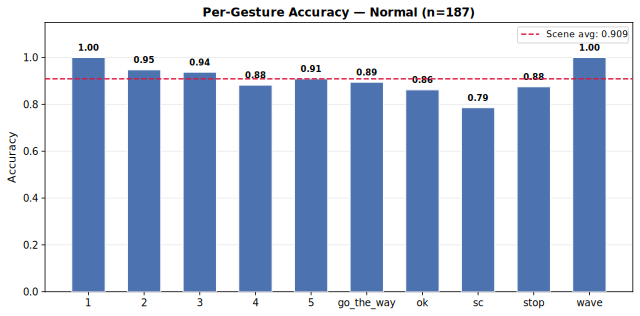

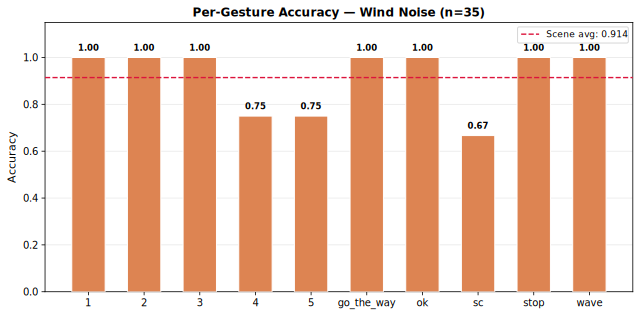

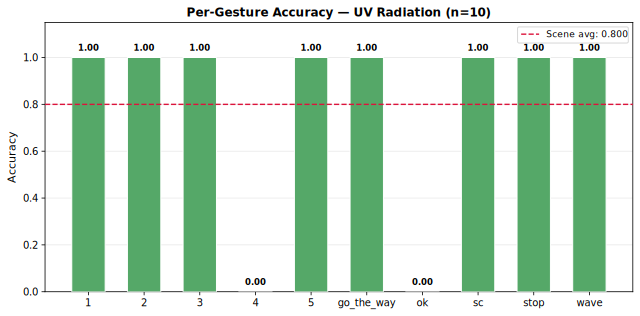

In [3]:
for env in ENVS:
    mask    = envs_te == env
    y_env   = y_te[mask]
    p_env   = pred_all[mask]
    n_env   = mask.sum()

    per_cls_acc = []
    for g in GESTURE_NAMES:
        lbl  = meta[meta['gesture_name']==g]['label'].iloc[0]
        m    = y_env == lbl
        acc  = accuracy_score(y_env[m], p_env[m]) if m.sum() > 0 else float('nan')
        per_cls_acc.append(acc)

    overall_env = accuracy_score(y_env, p_env)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(GESTURE_NAMES))
    bars = ax.bar(x, per_cls_acc, color=COLORS[env], edgecolor='white', width=0.6, zorder=3)
    ax.axhline(overall_env, color='crimson', linestyle='--', linewidth=1.4,
               label=f'Scene avg: {overall_env:.3f}', zorder=4)
    ax.set_xticks(x); ax.set_xticklabels(GESTURE_NAMES, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title(f'Per-Gesture Accuracy — {ENV_LABELS[env]}  (n={n_env})',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    for bar, acc in zip(bars, per_cls_acc):
        if not np.isnan(acc):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                    f'{acc:.2f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    fig.tight_layout()
    svg_path = PROJECT_ROOT / f'checkpoints/per_gesture_acc_{env}.svg'
    fig.savefig(svg_path, format='svg', bbox_inches='tight')
    display(SVG(filename=str(svg_path)))
    plt.close(fig)

## 2. Confusion Matrices by Scene

For each scene: count matrix (left) and percentage matrix (right).

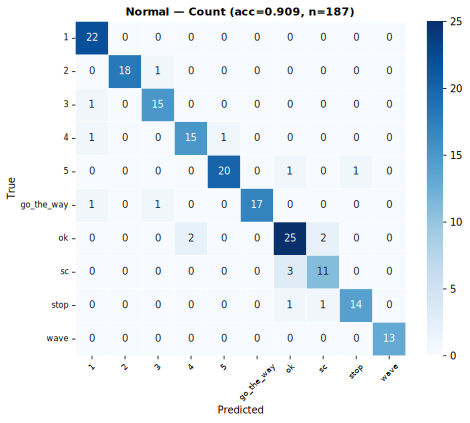

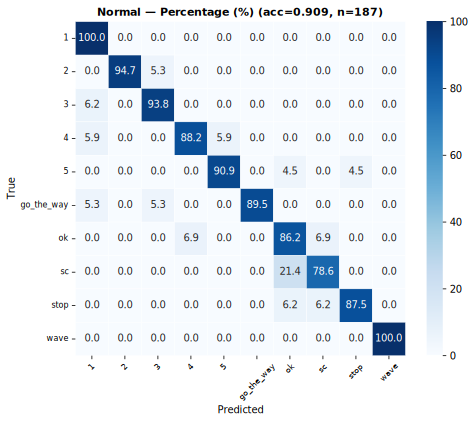

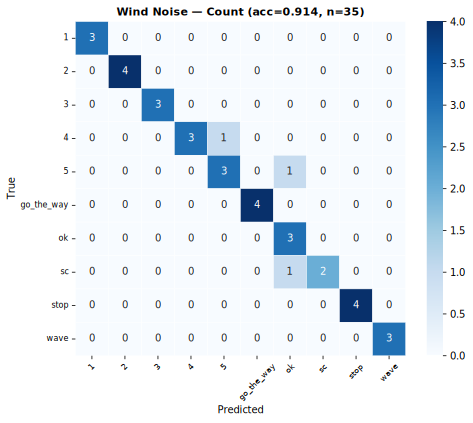

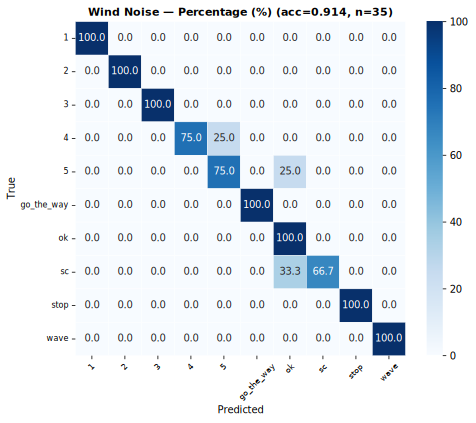

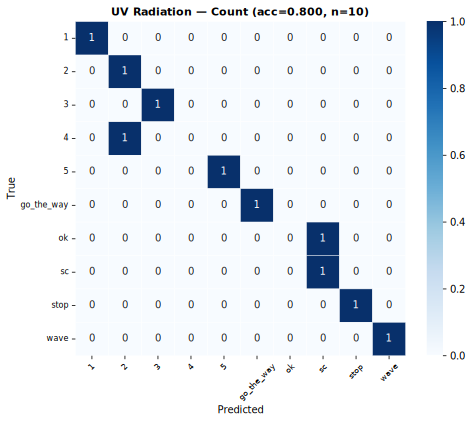

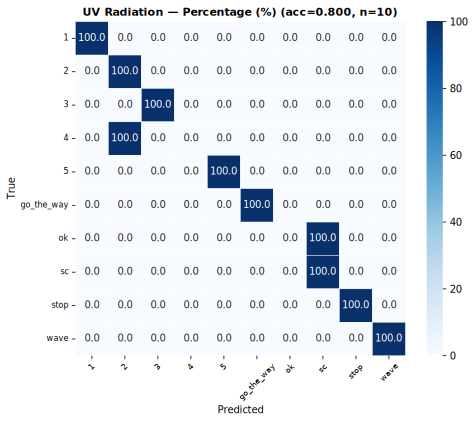

In [4]:
for env in ENVS:
    mask  = envs_te == env
    y_env = y_te[mask]
    p_env = pred_all[mask]
    n_env = mask.sum()
    acc_env = accuracy_score(y_env, p_env)

    cm_count = confusion_matrix(y_env, p_env, labels=label_order)
    cm_pct   = cm_count.astype(float) / cm_count.sum(axis=1, keepdims=True) * 100

    # ── count ──
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_count, annot=True, fmt='d', cmap='Blues',
                xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES,
                linewidths=0.4, linecolor='white', ax=ax)
    ax.set_title(f'{ENV_LABELS[env]} — Count  (acc={acc_env:.3f}, n={n_env})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
    fig.tight_layout()
    svg_path = PROJECT_ROOT / f'checkpoints/cm_count_{env}.svg'
    fig.savefig(svg_path, format='svg', bbox_inches='tight')
    display(SVG(filename=str(svg_path)))
    plt.close(fig)

    # ── percentage ──
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES,
                vmin=0, vmax=100, linewidths=0.4, linecolor='white', ax=ax)
    ax.set_title(f'{ENV_LABELS[env]} — Percentage (%)  (acc={acc_env:.3f}, n={n_env})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
    fig.tight_layout()
    svg_path = PROJECT_ROOT / f'checkpoints/cm_pct_{env}.svg'
    fig.savefig(svg_path, format='svg', bbox_inches='tight')
    display(SVG(filename=str(svg_path)))
    plt.close(fig)

## 3. Detailed Score Table

Per-gesture precision / recall / F1, per-scene accuracy, and overall accuracy.

In [5]:
from IPython.display import HTML

# per-gesture metrics (all test samples combined)
rows = []
for g in GESTURE_NAMES:
    lbl  = meta[meta['gesture_name']==g]['label'].iloc[0]
    m    = y_te == lbl
    if m.sum() == 0:
        rows.append({'Gesture': g, 'Support': 0, 'Precision': '-', 'Recall': '-', 'F1': '-', 'Accuracy': '-'})
        continue
    y_b = (y_te == lbl).astype(int)
    p_b = (pred_all == lbl).astype(int)
    tp  = ((pred_all == lbl) & (y_te == lbl)).sum()
    acc_g = accuracy_score(y_te[m], pred_all[m])
    rows.append({
        'Gesture':   g,
        'Support':   int(m.sum()),
        'Precision': f'{precision_score(y_b, p_b, zero_division=0):.3f}',
        'Recall':    f'{recall_score(y_b, p_b, zero_division=0):.3f}',
        'F1':        f'{f1_score(y_b, p_b, zero_division=0):.3f}',
        'Accuracy':  f'{acc_g:.3f}',
    })

df_gest = pd.DataFrame(rows)

# scene accuracies
scene_rows = []
for env in ENVS:
    mask = envs_te == env
    scene_rows.append({
        'Scene':    ENV_LABELS[env],
        'Samples':  int(mask.sum()),
        'Accuracy': f'{accuracy_score(y_te[mask], pred_all[mask]):.3f}' if mask.sum()>0 else '-',
    })
scene_rows.append({'Scene': 'Overall', 'Samples': len(y_te),
                   'Accuracy': f'{accuracy_score(y_te, pred_all):.3f}'})
df_scene = pd.DataFrame(scene_rows)

# ── render as HTML table ──────────────────────────────────────────────────
def style_df(df, title):
    s = df.style.set_caption(title)\
            .set_table_styles([
                {'selector': 'caption',
                 'props': [('font-size','13px'),('font-weight','bold'),
                           ('text-align','left'),('padding','6px 0')]},
                {'selector': 'th',
                 'props': [('background','#4C72B0'),('color','white'),
                           ('font-size','11px'),('text-align','center'),
                           ('padding','5px 10px')]},
                {'selector': 'td',
                 'props': [('font-size','11px'),('text-align','center'),
                           ('padding','4px 10px')]},
                {'selector': 'tr:nth-child(even)',
                 'props': [('background','#f0f4ff')]},
            ])\
            .hide(axis='index')
    return s

display(style_df(df_gest,  'Per-Gesture Scores (all test samples)'))
print()
display(style_df(df_scene, 'Per-Scene & Overall Accuracy'))

Gesture,Support,Precision,Recall,F1,Accuracy
1,26,0.897,1.000,0.945,1.000
2,24,0.958,0.958,0.958,0.958
3,20,0.905,0.950,0.927,0.950
4,22,0.900,0.818,0.857,0.818
5,27,0.923,0.889,0.906,0.889
go_the_way,24,1.000,0.917,0.957,0.917
ok,33,0.800,0.848,0.824,0.848
sc,18,0.778,0.778,0.778,0.778
stop,21,0.950,0.905,0.927,0.905
wave,17,1.000,1.000,1.000,1.000


Scene,Samples,Accuracy
Normal,187,0.909
Wind Noise,35,0.914
UV Radiation,10,0.800
Overall,232,0.905
